In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import math

# Paths
fd001_train_path = "../data/processed-nasa-data/data_cleaning_1/piecewise_rul_2/train_processed_rul_piecewise_125_fd001.csv"
fd002_train_path = "../data/processed-nasa-data/data_cleaning_1/piecewise_rul_2/train_processed_rul_piecewise_125_fd002.csv"
fd001_test_path = "../data/processed-nasa-data/data_cleaning_1/piecewise_rul_2/test_processed_rul_piecewise_125_fd001.csv"
fd002_test_path = "../data/processed-nasa-data/data_cleaning_1/piecewise_rul_2/test_processed_rul_piecewise_125_fd002.csv"

# Load data
df_fd001_train = pd.read_csv(fd001_train_path)
df_fd002_train = pd.read_csv(fd002_train_path)
df_fd001_test = pd.read_csv(fd001_test_path)
df_fd002_test = pd.read_csv(fd002_test_path)

# Quick view
print("FD001 Train shape:", df_fd001_train.shape)
print("\nFD002 Train shape:", df_fd002_train.shape)

def view_engine_max_cycle_distribution(
    datasets: dict,
    id_col: str = "id",
    cycle_col: str = "cycle",
    bins: int = 30
):
    """
    Plot and summarize distribution of max engine cycles per engine for multiple datasets.

    Parameters
    ----------
    datasets : dict
        Example: {"FD001 Train": df_fd001_train, "FD002 Train": df_fd002_train}
    id_col : str
        Engine identifier column.
    cycle_col : str
        Cycle column.
    bins : int
        Number of histogram bins.

    Returns
    -------
    summary_df : pd.DataFrame
        Per-dataset summary stats of max cycles per engine.
    max_cycles_dict : dict
        Per-dataset series of max cycles indexed by engine id.
    """
    max_cycles_dict = {}
    summary_rows = []

    for name, df in datasets.items():
        if id_col not in df.columns or cycle_col not in df.columns:
            raise ValueError(f"{name}: missing '{id_col}' or '{cycle_col}' column")

        max_cycles = (
            df[[id_col, cycle_col]]
            .dropna()
            .groupby(id_col)[cycle_col]
            .max()
            .sort_values()
        )

        max_cycles_dict[name] = max_cycles
        summary_rows.append({
            "dataset": name,
            "n_engines": int(max_cycles.shape[0]),
            "min": float(max_cycles.min()),
            "q1": float(max_cycles.quantile(0.25)),
            "median": float(max_cycles.median()),
            "mean": float(max_cycles.mean()),
            "q3": float(max_cycles.quantile(0.75)),
            "max": float(max_cycles.max()),
            "std": float(max_cycles.std(ddof=1)) if max_cycles.shape[0] > 1 else 0.0,
        })

    summary_df = pd.DataFrame(summary_rows).sort_values("dataset").reset_index(drop=True)

    # Plot one histogram per dataset
    n = len(max_cycles_dict)
    ncols = 2
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), constrained_layout=True)
    axes = axes.flatten() if n > 1 else [axes]

    for i, (name, s) in enumerate(max_cycles_dict.items()):
        axes[i].hist(s.values, bins=bins, alpha=0.8, edgecolor="black")
        axes[i].set_title(f"{name}: Max Cycle per Engine")
        axes[i].set_xlabel("Max cycle")
        axes[i].set_ylabel("Engine count")
        axes[i].grid(alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.show()
    display(summary_df)

    return summary_df, max_cycles_dict


def plot_all_sensors_for_machine(df, machine_id=1, title_prefix="Dataset", max_xticks=20):
    # Keep only one machine
    d = df[df["id"] == machine_id].sort_values("cycle")
    
    # Sensor columns (s1 ... s21)
    sensor_cols = [c for c in d.columns if c.startswith("s")]

    # Use cycle ticks at an interval so labels stay readable
    cycle_ticks = d["cycle"].astype(int).tolist()
    tick_step = max(1, math.ceil(len(cycle_ticks) / max_xticks))
    interval_ticks = cycle_ticks[::tick_step]
    if cycle_ticks and cycle_ticks[-1] not in interval_ticks:
        interval_ticks.append(cycle_ticks[-1])

    # Create subplot grid
    n = len(sensor_cols)
    ncols = 3
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows), sharex=False)
    axes = axes.flatten()

    for i, s in enumerate(sensor_cols):
        axes[i].plot(d["cycle"], d[s], linewidth=1.2)
        axes[i].set_title(s)
        axes[i].set_xlabel("Cycle number")
        axes[i].set_ylabel(s)
        axes[i].set_xticks(interval_ticks)
        axes[i].tick_params(axis="x", labelbottom=True, rotation=90, labelsize=7)
        axes[i].grid(alpha=0.3)

    # Hide unused panels
    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"{title_prefix} - All sensors vs cycle (machine id={machine_id})", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

FD001 Train shape: (20631, 27)

FD002 Train shape: (53759, 27)


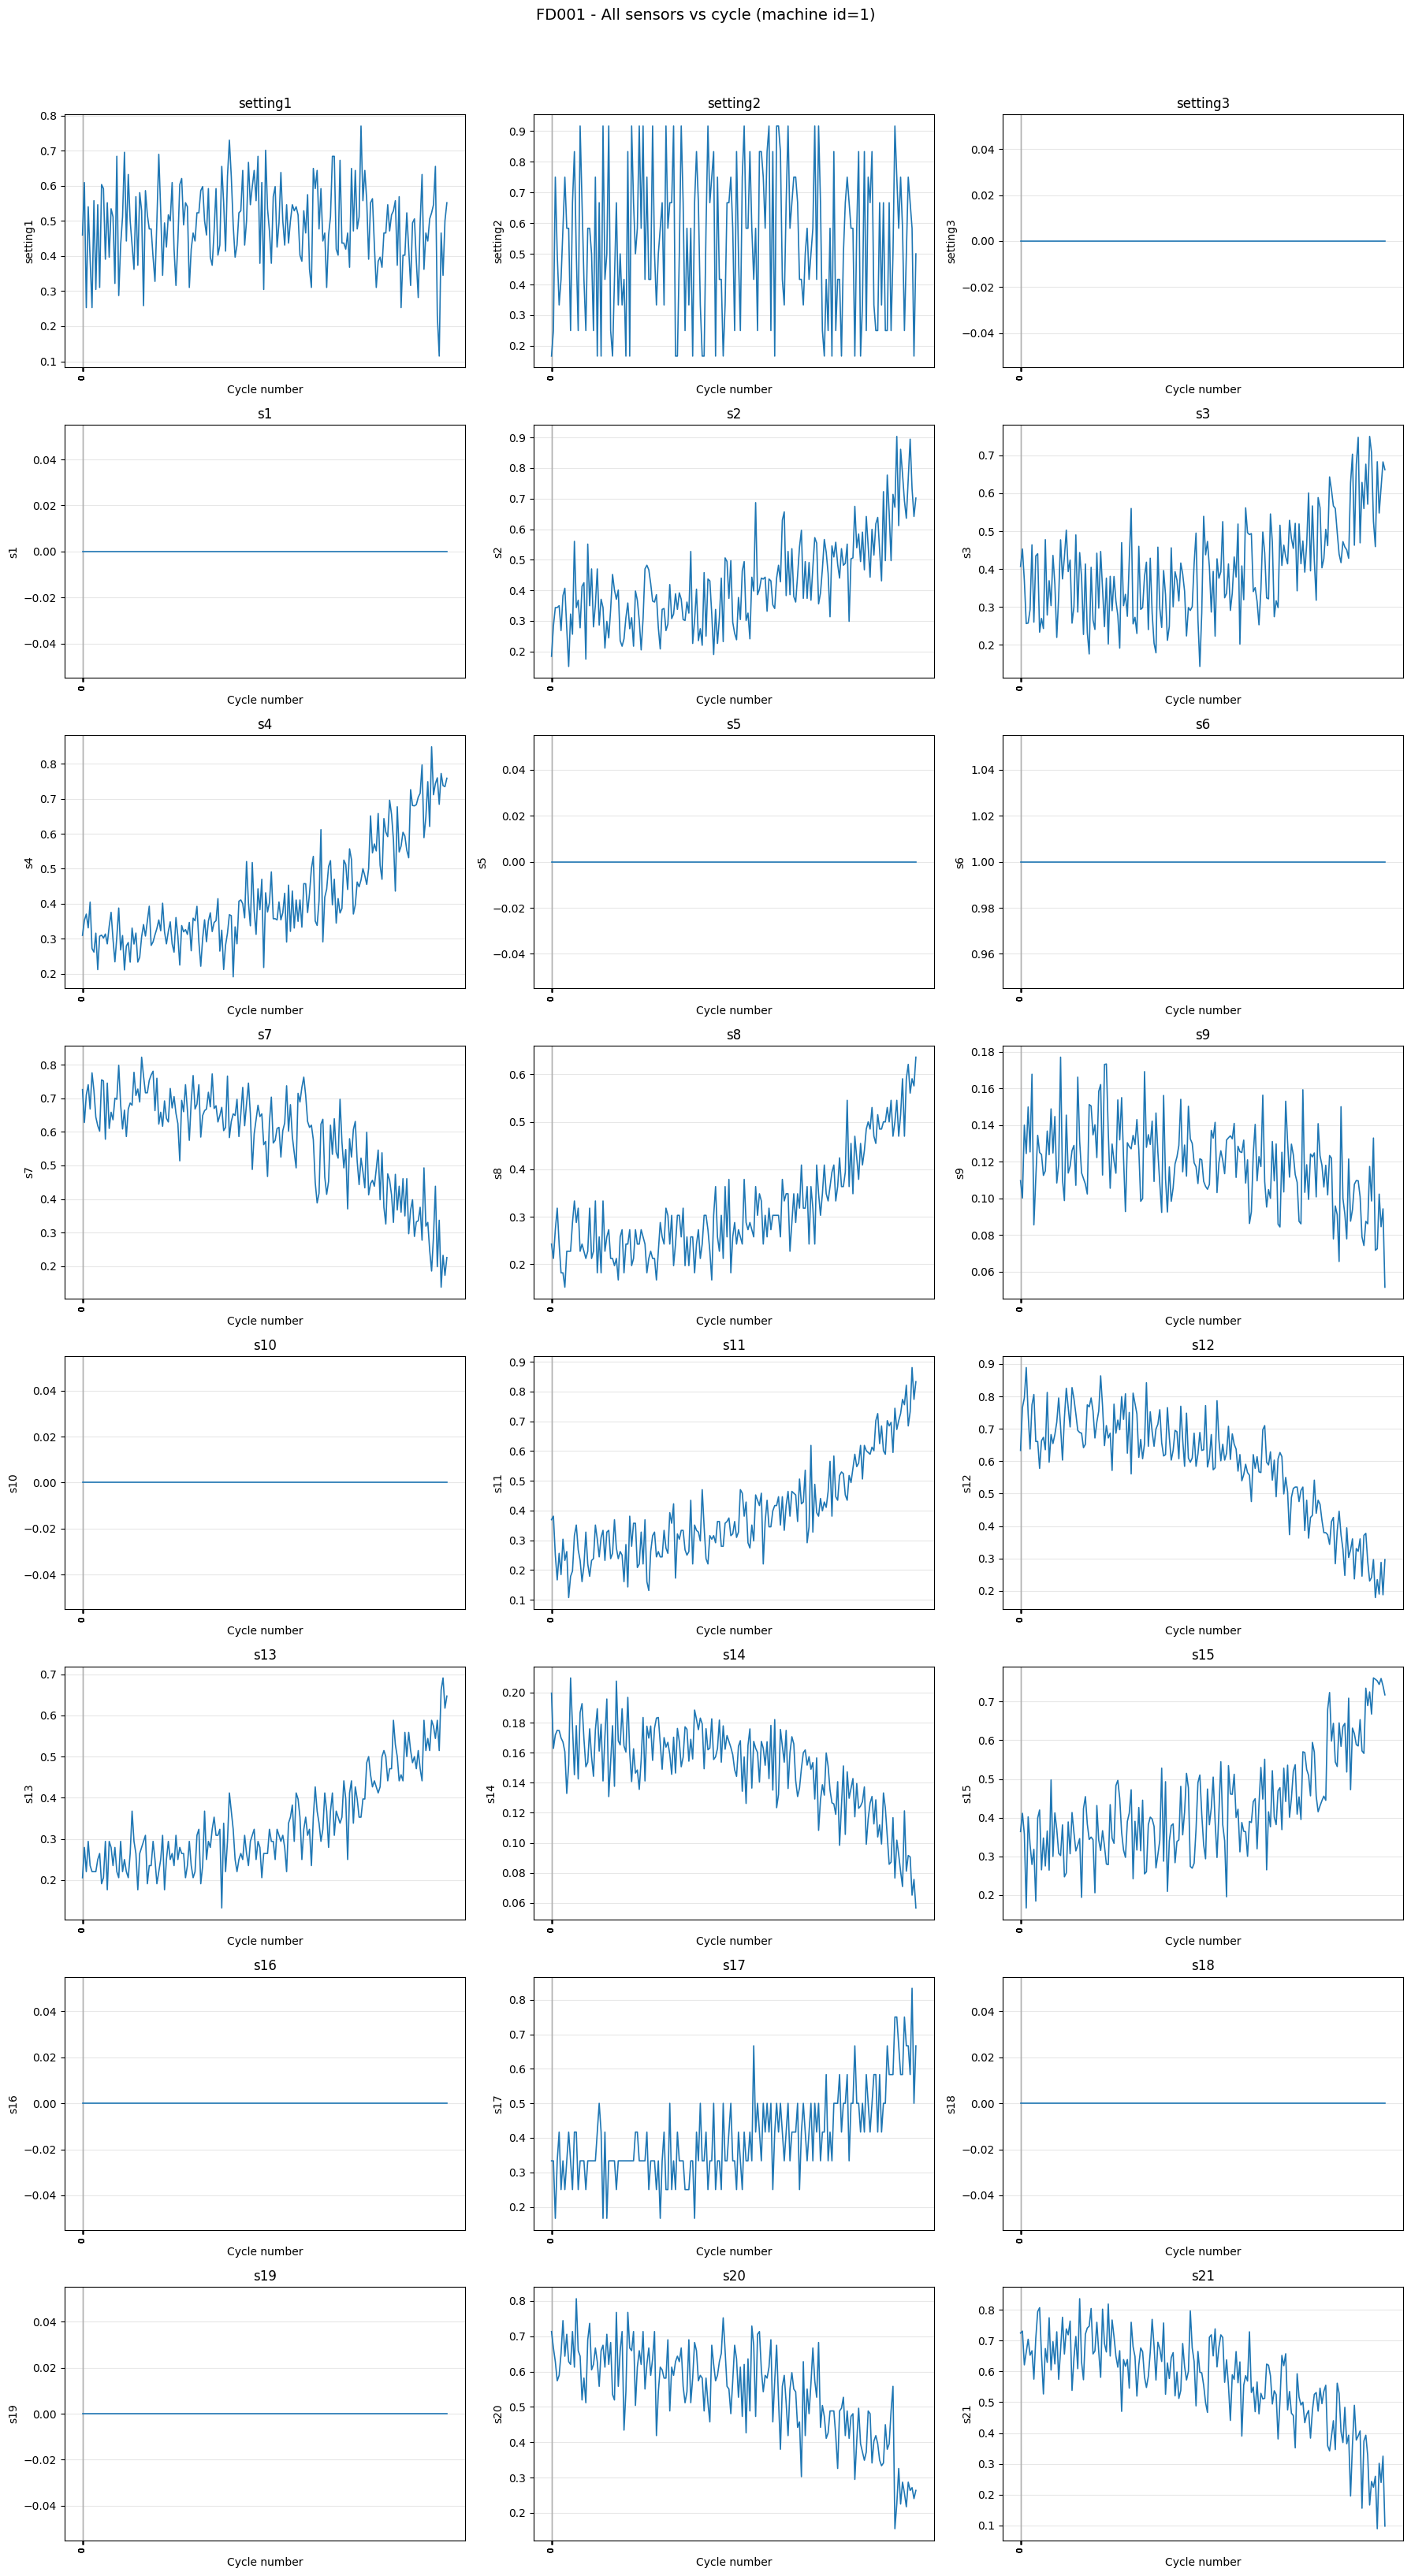

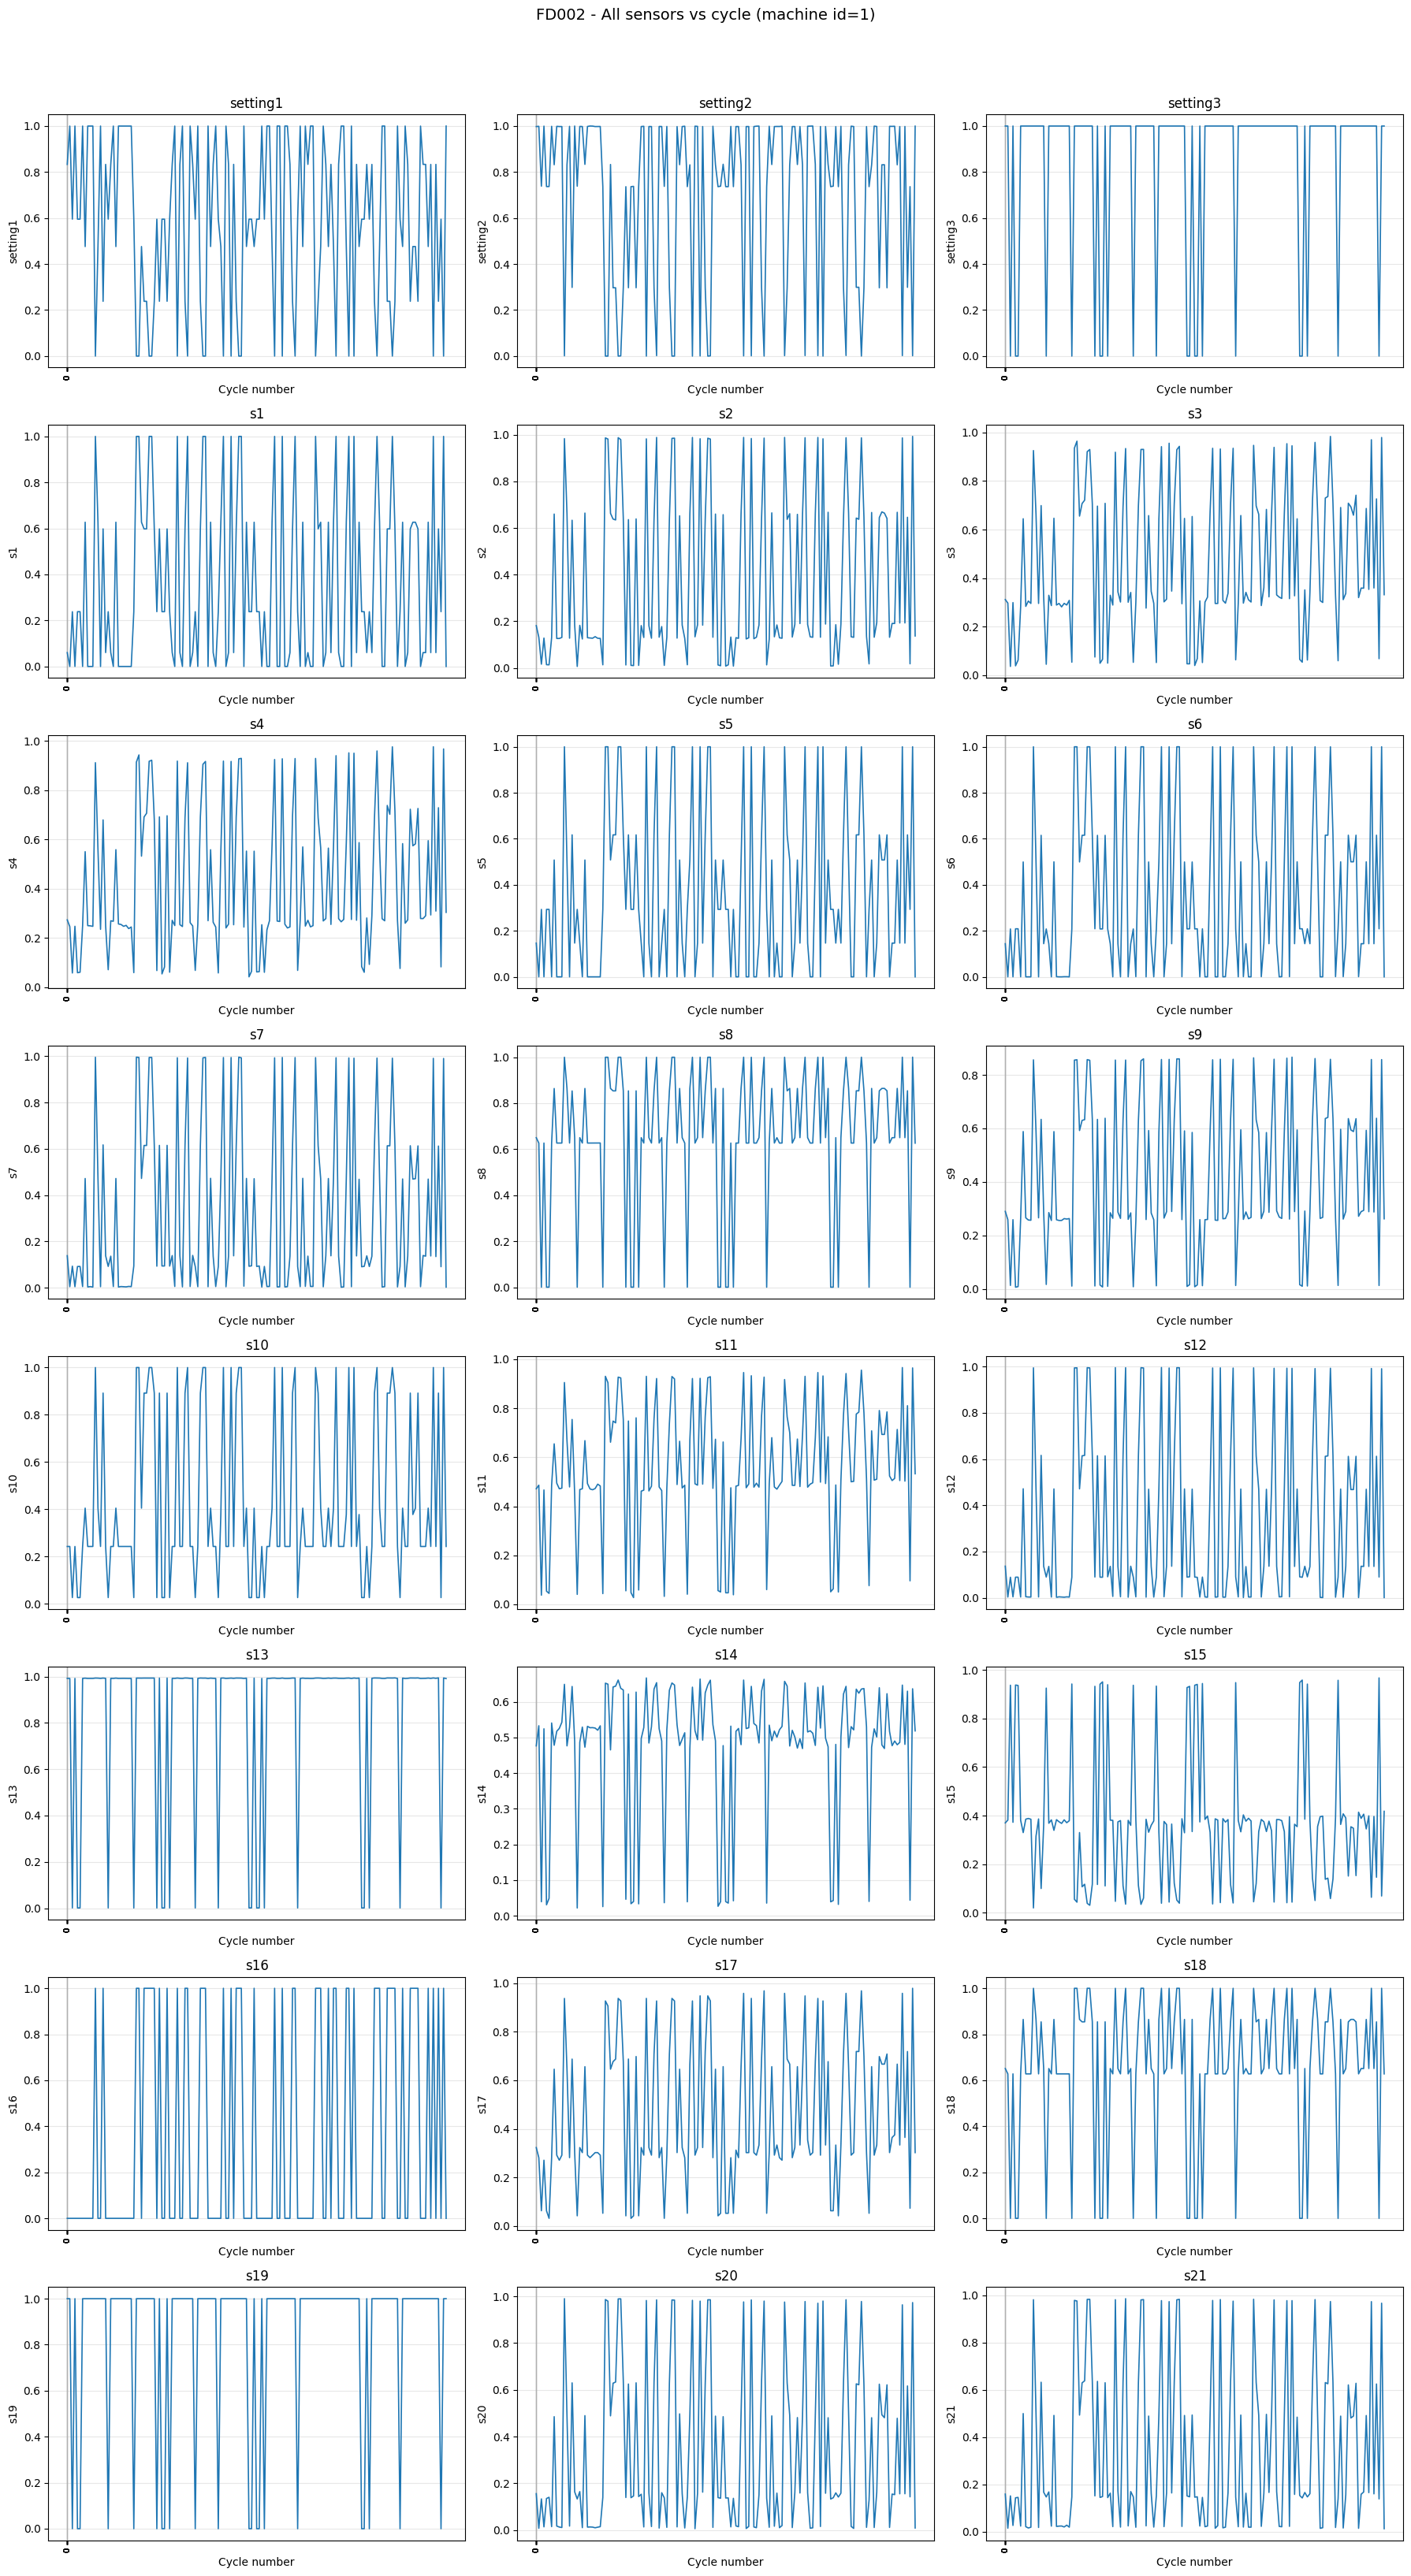

In [2]:
plot_all_sensors_for_machine(df_fd001_train, machine_id=1, title_prefix="FD001")
plot_all_sensors_for_machine(df_fd002_train, machine_id=1, title_prefix="FD002")

In [3]:
# Keep variable order from dataframe: setting1, setting2, setting3, s1 ...
ordered_variables = [
    c for c in df_fd001_train.columns
    if c.startswith("setting") or c.startswith("s")
]

# Variance across the entire dataset for each variable
var_fd001_train = df_fd001_train[ordered_variables].var()
var_fd002_train = df_fd002_train[ordered_variables].var()

variance_df = pd.DataFrame({
    "FD001_train_variance": var_fd001_train,
    "FD002_train_variance": var_fd002_train,
}, index=ordered_variables)

print("Variance by variable (ordered as in dataframe):")
display(variance_df.style.format("{:.6g}"))

Variance by variable (ordered as in dataframe):


,FD001_train_variance,FD002_train_variance
setting1,0.0158024,0.123244
setting2,0.0596426,0.135564
setting3,0,0.126696
s1,0,0.128318
s2,0.0226859,0.117057
s3,0.017866,0.0823695
s4,0.0230841,0.0822121
s5,0,0.113857
s6,0.0192928,0.116706
s7,0.0203139,0.121414


In [4]:
from pathlib import Path

# Low-variance features chosen from inspection (based on training data)
drop_cols_fd001 = ["setting3", "s1", "s5", "s10", "s16", "s18", "s19"]
drop_cols_fd002 = []  # no columns removed for FD002

# Columns that exist in each split
existing_drop_fd001_train = [c for c in drop_cols_fd001 if c in df_fd001_train.columns]
existing_drop_fd002_train = [c for c in drop_cols_fd002 if c in df_fd002_train.columns]
existing_drop_fd001_test = [c for c in existing_drop_fd001_train if c in df_fd001_test.columns]
existing_drop_fd002_test = [c for c in existing_drop_fd002_train if c in df_fd002_test.columns]

# Apply same drop policy to train and test
df_fd001_train_lowvar = df_fd001_train.drop(columns=existing_drop_fd001_train).copy()
df_fd002_train_lowvar = df_fd002_train.drop(columns=existing_drop_fd002_train).copy()
df_fd001_test_lowvar = df_fd001_test.drop(columns=existing_drop_fd001_test).copy()
df_fd002_test_lowvar = df_fd002_test.drop(columns=existing_drop_fd002_test).copy()

print("FD001 train:", df_fd001_train.shape, "->", df_fd001_train_lowvar.shape)
print("FD002 train:", df_fd002_train.shape, "->", df_fd002_train_lowvar.shape)
print("FD001 test:", df_fd001_test.shape, "->", df_fd001_test_lowvar.shape)
print("FD002 test:", df_fd002_test.shape, "->", df_fd002_test_lowvar.shape)
print("Dropped FD001:", existing_drop_fd001_train)
print("Dropped FD002:", existing_drop_fd002_train)

# Save outputs
output_dir = Path("../data/processed-nasa-data/feature_engineering_2/low_variance_1")
output_dir.mkdir(parents=True, exist_ok=True)

fd001_train_out = output_dir / "train_fd001_low_variance_1_125.csv"
fd002_train_out = output_dir / "train_fd002_low_variance_1_125.csv"
fd001_test_out = output_dir / "test_fd001_low_variance_1_125.csv"
fd002_test_out = output_dir / "test_fd002_low_variance_1_125.csv"

df_fd001_train_lowvar.to_csv(fd001_train_out, index=False)
df_fd002_train_lowvar.to_csv(fd002_train_out, index=False)
df_fd001_test_lowvar.to_csv(fd001_test_out, index=False)
df_fd002_test_lowvar.to_csv(fd002_test_out, index=False)

print("Saved:", fd001_train_out)
print("Saved:", fd002_train_out)
print("Saved:", fd001_test_out)
print("Saved:", fd002_test_out)

FD001 train: (20631, 27) -> (20631, 20)
FD002 train: (53759, 27) -> (53759, 27)
FD001 test: (13096, 27) -> (13096, 20)
FD002 test: (33991, 27) -> (33991, 27)
Dropped FD001: ['setting3', 's1', 's5', 's10', 's16', 's18', 's19']
Dropped FD002: []
Saved: ..\data\processed-nasa-data\feature_engineering_2\low_variance_1\train_fd001_low_variance_1_125.csv
Saved: ..\data\processed-nasa-data\feature_engineering_2\low_variance_1\train_fd002_low_variance_1_125.csv
Saved: ..\data\processed-nasa-data\feature_engineering_2\low_variance_1\test_fd001_low_variance_1_125.csv
Saved: ..\data\processed-nasa-data\feature_engineering_2\low_variance_1\test_fd002_low_variance_1_125.csv


In [5]:
# Correlation with RUL BEFORE pruning using correlation coefficients (run this near the top, after loading df_fd001/df_fd002)
def corr_with_rul_before_culling(df, dataset_name, top_n=15):
    # Use only settings + sensors as candidate features
    feature_cols = [
        c for c in df.columns
        if c.startswith("setting") or c.startswith("s")
    ]

    # Compute feature-to-RUL correlation
    corr_series = df[feature_cols + ["RUL"]].corr()["RUL"].drop("RUL")
    corr_table = pd.DataFrame({
        "corr_with_RUL": corr_series,
        "abs_corr_with_RUL": corr_series.abs(),
    }).sort_values("abs_corr_with_RUL", ascending=False)

    print(f"\n{dataset_name} - Feature correlation with RUL (sorted by |corr|):")
    display(corr_table)

    return corr_table

# Run on original datasets (before any correlation-based pruning rounds)
corr_rul_fd001_before = corr_with_rul_before_culling(df_fd001_train_lowvar, "FD001")
corr_rul_fd002_before = corr_with_rul_before_culling(df_fd002_train_lowvar, "FD002")


FD001 - Feature correlation with RUL (sorted by |corr|):


,corr_with_RUL,abs_corr_with_RUL
s11,-0.775230,0.775230
s4,-0.757157,0.757157
s12,0.748870,0.748870
s7,0.733021,0.733021
s15,-0.720858,0.720858
s21,0.707334,0.707334
s20,0.704626,0.704626
s17,-0.680829,0.680829
s2,-0.678458,0.678458
s3,-0.655030,0.655030



FD002 - Feature correlation with RUL (sorted by |corr|):


,corr_with_RUL,abs_corr_with_RUL
s16,-0.087709,0.087709
s14,-0.056143,0.056143
s11,-0.055428,0.055428
s4,-0.047688,0.047688
s15,-0.039544,0.039544
s17,-0.032691,0.032691
s3,-0.032421,0.032421
s9,-0.020981,0.020981
s2,-0.007353,0.007353
s20,0.006539,0.006539


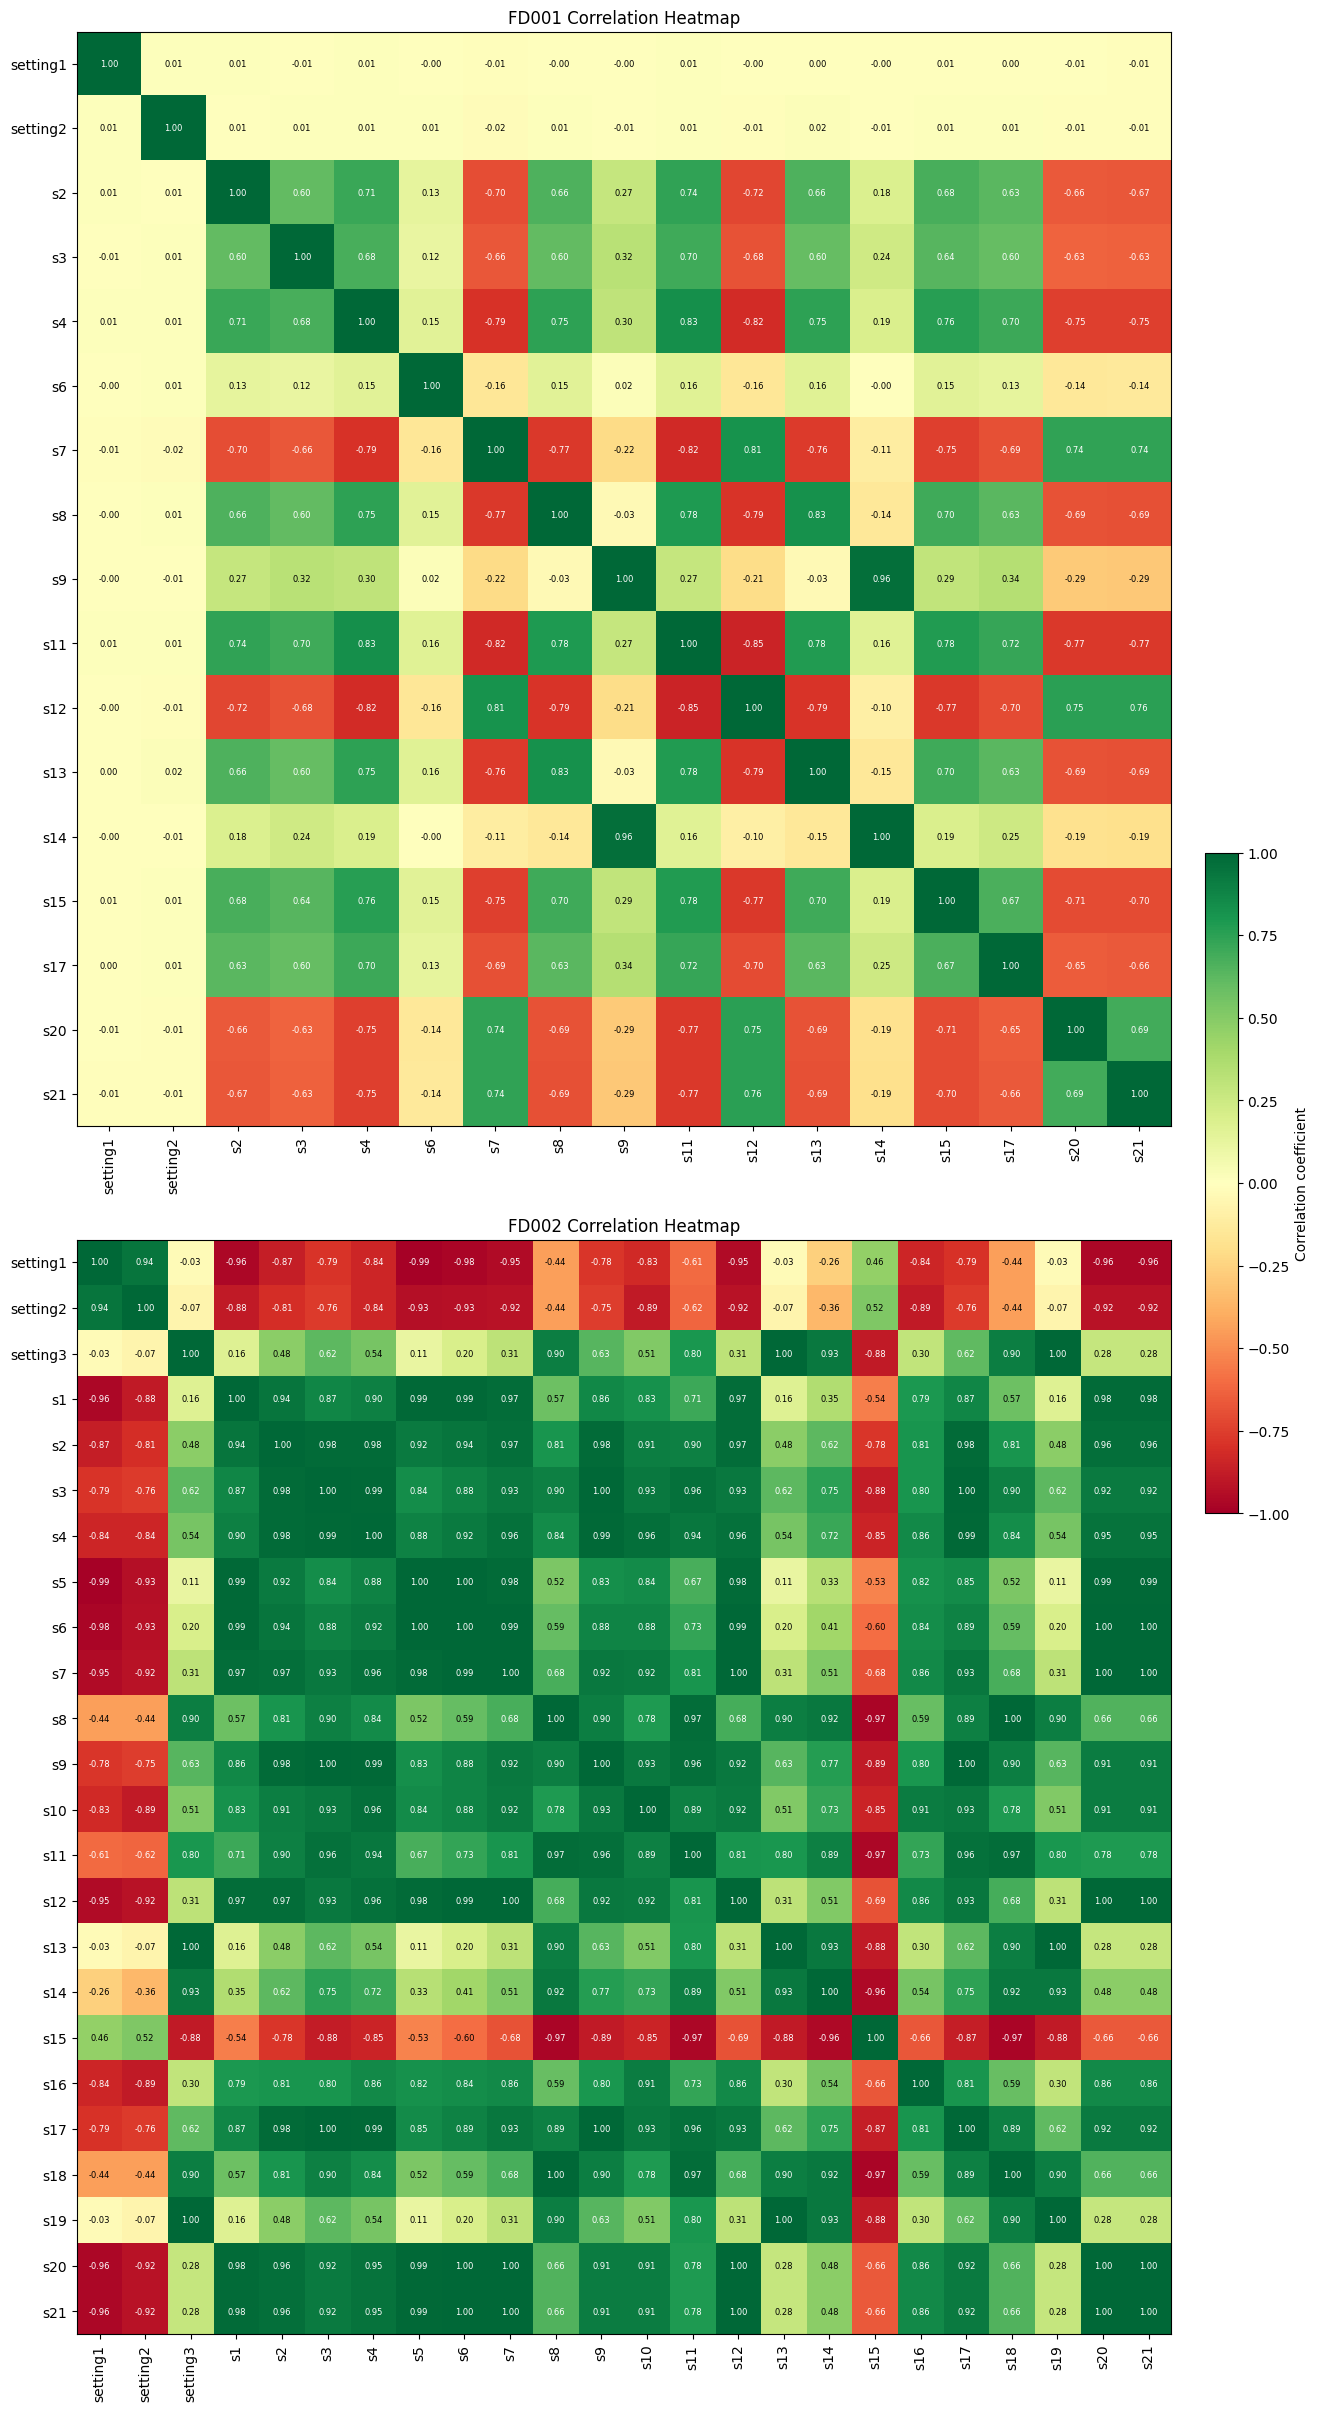

In [6]:
# Correlation across settings + sensors, keeping dataframe order: setting1, setting2, setting3, s1 ...
corr_source_fd001 = df_fd001_train_lowvar 
corr_source_fd002 = df_fd002_train_lowvar 

ordered_vars_fd001 = [
    c for c in corr_source_fd001.columns
    if c.startswith("setting") or c.startswith("s")
]
ordered_vars_fd002 = [
    c for c in corr_source_fd002.columns
    if c.startswith("setting") or c.startswith("s")
]

corr_fd001 = corr_source_fd001[ordered_vars_fd001].corr()
corr_fd002 = corr_source_fd002[ordered_vars_fd002].corr()

# Red = negative correlation, white = zero, green = positive correlation
fig, axes = plt.subplots(2, 1, figsize=(18, 24), constrained_layout=True)

img1 = axes[0].imshow(corr_fd001.values, cmap="RdYlGn", vmin=-1, vmax=1)
axes[0].set_title("FD001 Correlation Heatmap")
axes[0].set_xticks(range(len(ordered_vars_fd001)))
axes[0].set_yticks(range(len(ordered_vars_fd001)))
axes[0].set_xticklabels(ordered_vars_fd001, rotation=90)
axes[0].set_yticklabels(ordered_vars_fd001)

img2 = axes[1].imshow(corr_fd002.values, cmap="RdYlGn", vmin=-1, vmax=1)
axes[1].set_title("FD002 Correlation Heatmap")
axes[1].set_xticks(range(len(ordered_vars_fd002)))
axes[1].set_yticks(range(len(ordered_vars_fd002)))
axes[1].set_xticklabels(ordered_vars_fd002, rotation=90)
axes[1].set_yticklabels(ordered_vars_fd002)

# Put correlation values inside each heatmap cell
for r in range(corr_fd001.shape[0]):
    for c in range(corr_fd001.shape[1]):
        val = corr_fd001.iat[r, c]
        text_color = "white" if abs(val) > 0.6 else "black"
        axes[0].text(c, r, f"{val:.2f}", ha="center", va="center", color=text_color, fontsize=6)

for r in range(corr_fd002.shape[0]):
    for c in range(corr_fd002.shape[1]):
        val = corr_fd002.iat[r, c]
        text_color = "white" if abs(val) > 0.6 else "black"
        axes[1].text(c, r, f"{val:.2f}", ha="center", va="center", color=text_color, fontsize=6)

cbar = fig.colorbar(img2, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label("Correlation coefficient")

plt.show()

Count of other variables with correlation >= 0.85 (sorted by FD001):


,FD001_high_corr_count,FD001_highest_corr,FD001_highest_corr_with
s14,1,0.963157,s9
s9,1,0.963157,s14
setting1,0,-0.014559,s21
setting2,0,0.018156,s13
s4,0,0.830136,s11
s6,0,0.160014,s11
s2,0,0.740020,s11
s3,0,0.695900,s11
s8,0,0.826084,s13
s7,0,-0.822805,s11


Count of other variables with correlation >= 0.9 (sorted by FD002):


,FD002_high_corr_count,FD002_highest_corr,FD002_highest_corr_with
s7,14,0.999993,s12
s21,14,0.999898,s20
s20,14,0.999898,s21
s12,14,0.999993,s7
s9,12,0.997853,s17
s2,12,0.983065,s17
s4,11,0.990213,s17
s3,10,0.998680,s17
s10,10,0.961586,s4
s17,10,0.998680,s3


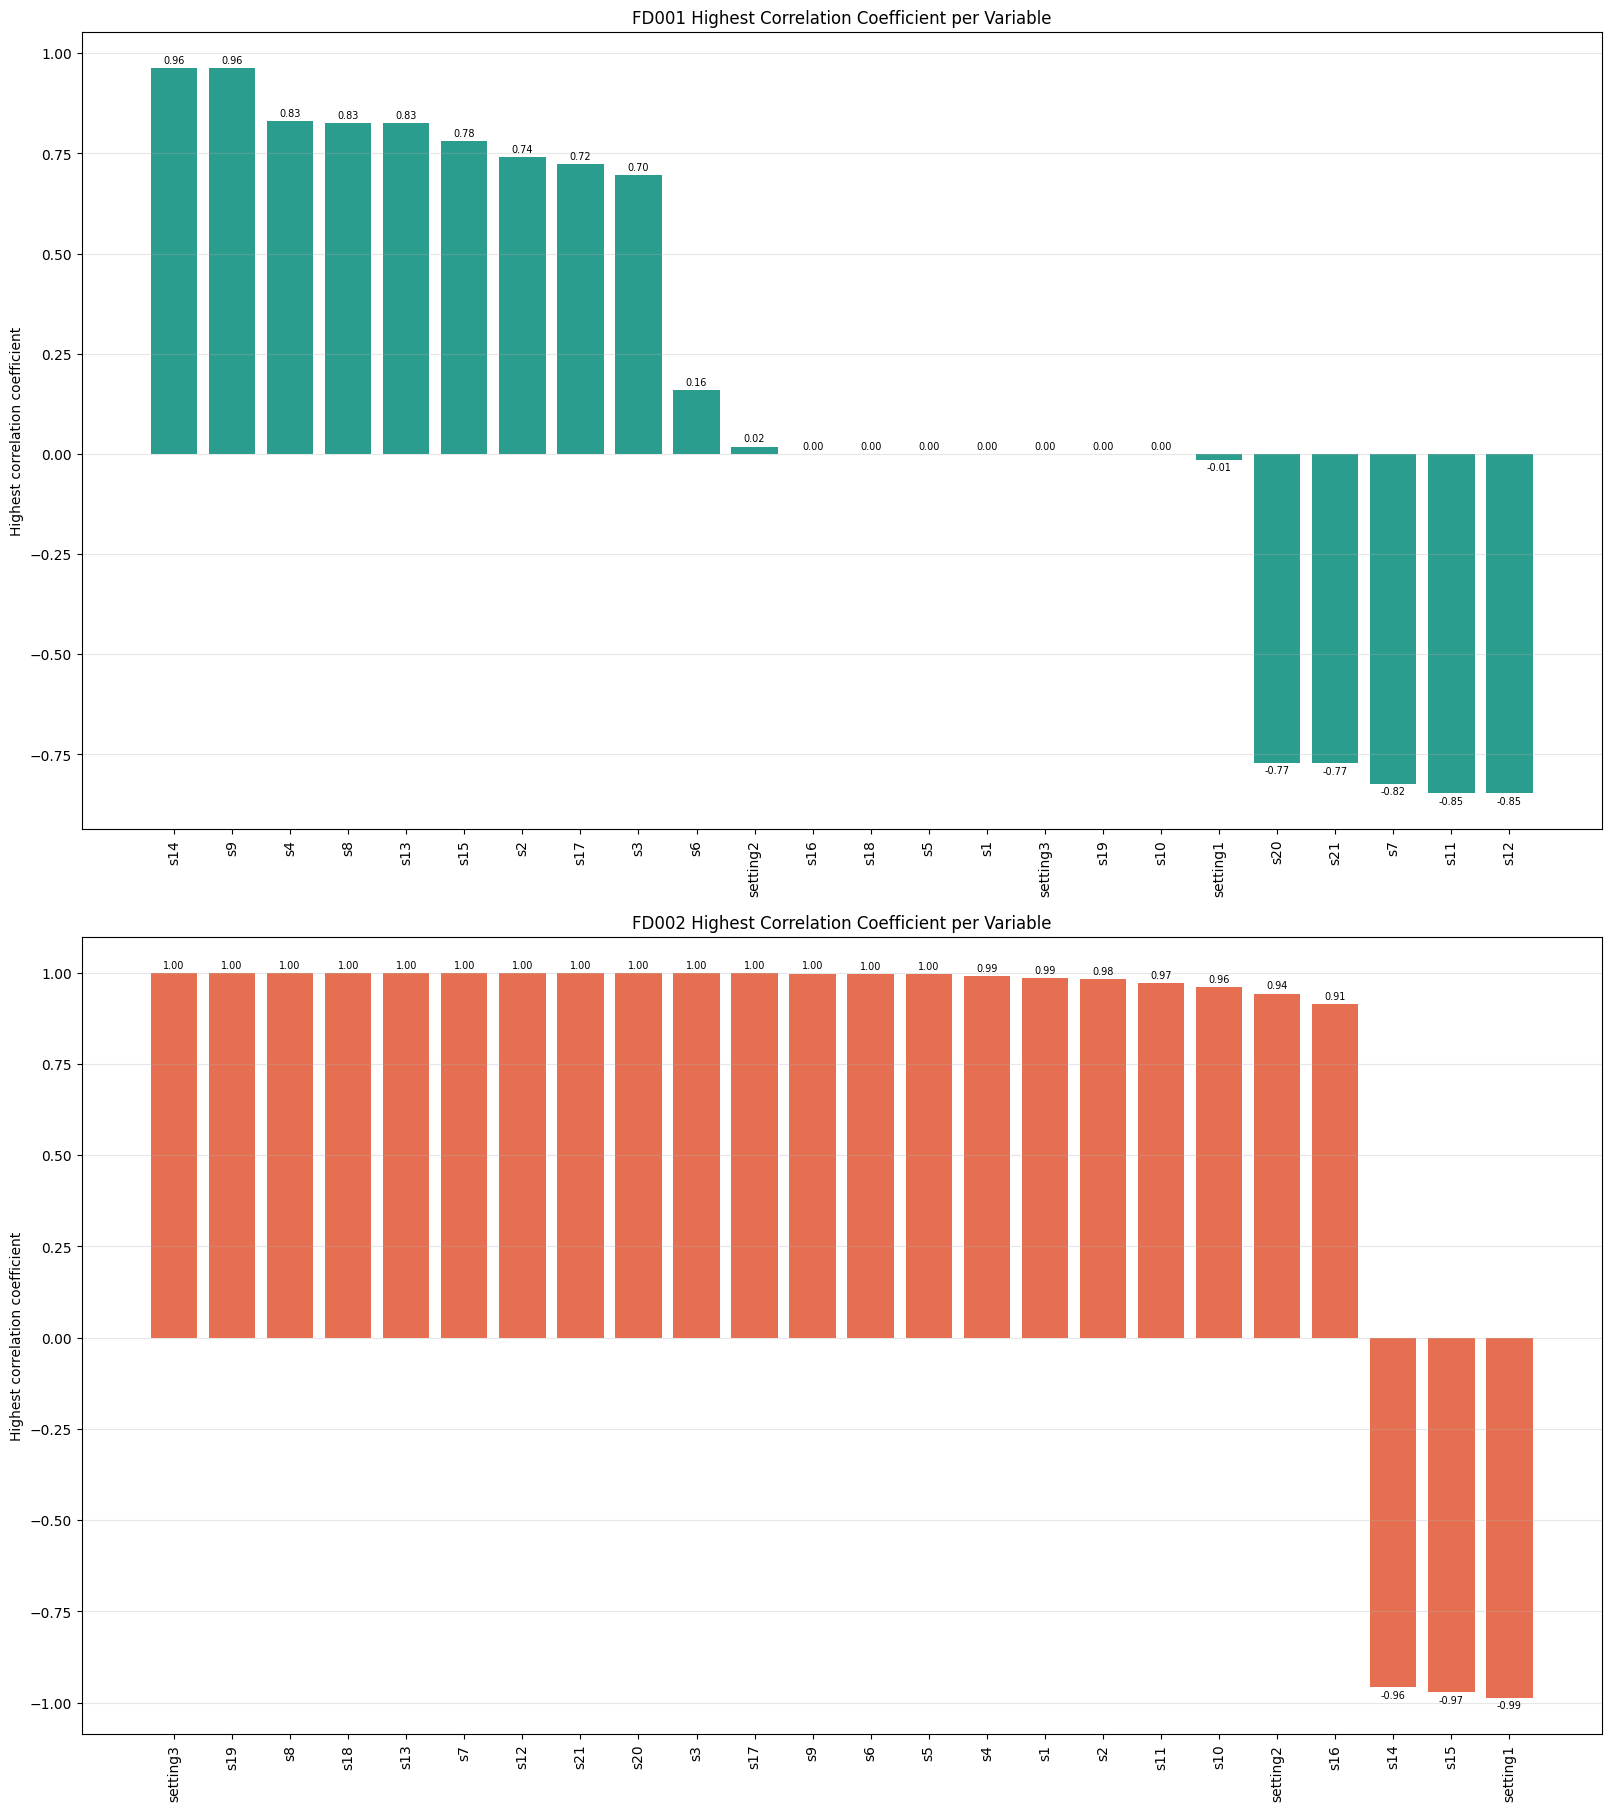

In [7]:
# For each variable, count how many other variables it has correlation >= 0.85
fd_001_threshold = 0.85
fd_002_threshold = 0.9

def count_high_correlation(corr_df, threshold=0.85):
    # True where absolute correlation meets threshold
    high_corr_mask = corr_df.abs() >= threshold
    
    # Remove self-correlation on the diagonal
    for i in range(len(high_corr_mask)):
        high_corr_mask.iat[i, i] = False
    
    # Count how many other variables are highly correlated with each variable
    return high_corr_mask.sum(axis=1).astype(int)

def max_correlation_info(corr_df):
    corr_no_diag = corr_df.copy()
    for i in range(len(corr_no_diag)):
        corr_no_diag.iat[i, i] = 0.0
    
    abs_corr = corr_no_diag.abs()
    max_pair = abs_corr.idxmax(axis=1)
    max_abs_corr = abs_corr.max(axis=1)
    max_corr_signed = pd.Series(index=corr_df.index, dtype=float)

    for col in corr_df.index:
        pair_col = max_pair[col]
        max_corr_signed[col] = corr_no_diag.loc[col, pair_col]

    return pd.DataFrame({
        "highest_corr_coeff": max_corr_signed,
        "highest_corr_abs": max_abs_corr,
        "highest_corr_with": max_pair,
    })

high_corr_count_fd001 = count_high_correlation(corr_fd001, threshold=fd_001_threshold)
high_corr_count_fd002 = count_high_correlation(corr_fd002, threshold=fd_002_threshold)
max_corr_fd001 = max_correlation_info(corr_fd001)
max_corr_fd002 = max_correlation_info(corr_fd002)

# Keep order as setting1, setting2, ... then sensors; fill missing with 0 and cast to int
ordered_union = list(dict.fromkeys(list(high_corr_count_fd001.index) + list(high_corr_count_fd002.index)))

high_corr_summary = pd.DataFrame(index=ordered_union)
high_corr_summary["FD001_high_corr_count"] = high_corr_count_fd001.reindex(ordered_union).fillna(0).astype(int)
high_corr_summary["FD002_high_corr_count"] = high_corr_count_fd002.reindex(ordered_union).fillna(0).astype(int)
high_corr_summary["FD001_highest_corr"] = max_corr_fd001["highest_corr_coeff"].reindex(ordered_union).fillna(0.0)
high_corr_summary["FD002_highest_corr"] = max_corr_fd002["highest_corr_coeff"].reindex(ordered_union).fillna(0.0)
high_corr_summary["FD001_highest_corr_with"] = max_corr_fd001["highest_corr_with"].reindex(ordered_union).fillna("-")
high_corr_summary["FD002_highest_corr_with"] = max_corr_fd002["highest_corr_with"].reindex(ordered_union).fillna("-")

# Two separate sorted views
high_corr_summary_sorted_fd001 = high_corr_summary.sort_values(
    by="FD001_high_corr_count",
    ascending=False
)
high_corr_summary_sorted_fd002 = high_corr_summary.sort_values(
    by="FD002_high_corr_count",
    ascending=False
)

print(f"Count of other variables with correlation >= {fd_001_threshold} (sorted by FD001):")
display(high_corr_summary_sorted_fd001[["FD001_high_corr_count", "FD001_highest_corr", "FD001_highest_corr_with"]])

print(f"Count of other variables with correlation >= {fd_002_threshold} (sorted by FD002):")
display(high_corr_summary_sorted_fd002[["FD002_high_corr_count", "FD002_highest_corr", "FD002_highest_corr_with"]])

# Plot highest correlation coefficient for each variable
plot_fd001 = high_corr_summary[["FD001_highest_corr"]].copy()
plot_fd001 = plot_fd001.sort_values("FD001_highest_corr", ascending=False)
plot_fd002 = high_corr_summary[["FD002_highest_corr"]].copy()
plot_fd002 = plot_fd002.sort_values("FD002_highest_corr", ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(16, 18), constrained_layout=True)

bars1 = axes[0].bar(range(len(plot_fd001)), plot_fd001["FD001_highest_corr"], color="#2a9d8f")
axes[0].set_title("FD001 Highest Correlation Coefficient per Variable")
axes[0].set_ylabel("Highest correlation coefficient")
axes[0].set_xticks(range(len(plot_fd001)))
axes[0].set_xticklabels(plot_fd001.index, rotation=90)
axes[0].grid(axis="y", alpha=0.3)
axes[0].bar_label(bars1, fmt="%.2f", fontsize=7, padding=2)

bars2 = axes[1].bar(range(len(plot_fd002)), plot_fd002["FD002_highest_corr"], color="#e76f51")
axes[1].set_title("FD002 Highest Correlation Coefficient per Variable")
axes[1].set_ylabel("Highest correlation coefficient")
axes[1].set_xticks(range(len(plot_fd002)))
axes[1].set_xticklabels(plot_fd002.index, rotation=90)
axes[1].grid(axis="y", alpha=0.3)
axes[1].bar_label(bars2, fmt="%.2f", fontsize=7, padding=2)

plt.show()

In [8]:
# FD001: 
# From the above table, we will decide to remove between s14 because of high correlation with s9 + low RUL coeff
# We will also remove s12 because of high correlation with s11 but also relatively lower coeff with RUL than s11
# Final removal: s14, s12 

# FD002:
# A lot more complicated, lots of target values!
# Let's first try removing any sensor value that appears twice or more  on highest coefficient

In [9]:
# Remove s14, s12 rows from FD001 train and test set and save it 
from pathlib import Path

# Remove chosen correlated FD001 features from both train and test
fd001_corr_drop_cols = ["s14", "s12"]

fd001_drop_train = [c for c in fd001_corr_drop_cols if c in df_fd001_train_lowvar.columns]
fd001_drop_test = [c for c in fd001_corr_drop_cols if c in df_fd001_test_lowvar.columns]

df_fd001_train_corr_pruned = df_fd001_train_lowvar.drop(columns=fd001_drop_train).copy()
df_fd001_test_corr_pruned = df_fd001_test_lowvar.drop(columns=fd001_drop_test).copy()

save_dir = Path("../data/processed-nasa-data/feature_engineering_2/high_correlation_2/manual_fd001_1")
save_dir.mkdir(parents=True, exist_ok=True)

train_out = save_dir / "train_fd001_drop_s14_s12.csv"
test_out = save_dir / "test_fd001_drop_s14_s12.csv"

df_fd001_train_corr_pruned.to_csv(train_out, index=False)
df_fd001_test_corr_pruned.to_csv(test_out, index=False)

print("Dropped (train):", fd001_drop_train)
print("Dropped (test):", fd001_drop_test)
print("Train shape:", df_fd001_train_lowvar.shape, "->", df_fd001_train_corr_pruned.shape)
print("Test shape:", df_fd001_test_lowvar.shape, "->", df_fd001_test_corr_pruned.shape)
print("Saved:", train_out)
print("Saved:", test_out)

Dropped (train): ['s14', 's12']
Dropped (test): ['s14', 's12']
Train shape: (20631, 20) -> (20631, 18)
Test shape: (13096, 20) -> (13096, 18)
Saved: ..\data\processed-nasa-data\feature_engineering_2\high_correlation_2\manual_fd001_1\train_fd001_drop_s14_s12.csv
Saved: ..\data\processed-nasa-data\feature_engineering_2\high_correlation_2\manual_fd001_1\test_fd001_drop_s14_s12.csv


In [10]:
# Remove s14, s11 rows from FD001 train and test set and save it 
from pathlib import Path

# Remove chosen correlated FD001 features from both train and test
fd001_corr_drop_cols = ["s14", "s11"]

fd001_drop_train = [c for c in fd001_corr_drop_cols if c in df_fd001_train_lowvar.columns]
fd001_drop_test = [c for c in fd001_corr_drop_cols if c in df_fd001_test_lowvar.columns]

df_fd001_train_corr_pruned = df_fd001_train_lowvar.drop(columns=fd001_drop_train).copy()
df_fd001_test_corr_pruned = df_fd001_test_lowvar.drop(columns=fd001_drop_test).copy()

save_dir = Path("../data/processed-nasa-data/feature_engineering_2/high_correlation_2/manual_fd001_1")
save_dir.mkdir(parents=True, exist_ok=True)

train_out = save_dir / "train_fd001_drop_s14_s11.csv"
test_out = save_dir / "test_fd001_drop_s14_s11.csv"

df_fd001_train_corr_pruned.to_csv(train_out, index=False)
df_fd001_test_corr_pruned.to_csv(test_out, index=False)

print("Dropped (train):", fd001_drop_train)
print("Dropped (test):", fd001_drop_test)
print("Train shape:", df_fd001_train_lowvar.shape, "->", df_fd001_train_corr_pruned.shape)
print("Test shape:", df_fd001_test_lowvar.shape, "->", df_fd001_test_corr_pruned.shape)
print("Saved:", train_out)
print("Saved:", test_out)

Dropped (train): ['s14', 's11']
Dropped (test): ['s14', 's11']
Train shape: (20631, 20) -> (20631, 18)
Test shape: (13096, 20) -> (13096, 18)
Saved: ..\data\processed-nasa-data\feature_engineering_2\high_correlation_2\manual_fd001_1\train_fd001_drop_s14_s11.csv
Saved: ..\data\processed-nasa-data\feature_engineering_2\high_correlation_2\manual_fd001_1\test_fd001_drop_s14_s11.csv


In [11]:
# Remove s14 row from FD001 train and test set and save it 
from pathlib import Path

# Remove chosen correlated FD001 features from both train and test
fd001_corr_drop_cols = ["s14"]

fd001_drop_train = [c for c in fd001_corr_drop_cols if c in df_fd001_train_lowvar.columns]
fd001_drop_test = [c for c in fd001_corr_drop_cols if c in df_fd001_test_lowvar.columns]

df_fd001_train_corr_pruned = df_fd001_train_lowvar.drop(columns=fd001_drop_train).copy()
df_fd001_test_corr_pruned = df_fd001_test_lowvar.drop(columns=fd001_drop_test).copy()

save_dir = Path("../data/processed-nasa-data/feature_engineering_2/high_correlation_2/manual_fd001_1")
save_dir.mkdir(parents=True, exist_ok=True)

train_out = save_dir / "train_fd001_drop_s14.csv"
test_out = save_dir / "test_fd001_drop_s14.csv"

df_fd001_train_corr_pruned.to_csv(train_out, index=False)
df_fd001_test_corr_pruned.to_csv(test_out, index=False)

print("Dropped (train):", fd001_drop_train)
print("Dropped (test):", fd001_drop_test)
print("Train shape:", df_fd001_train_lowvar.shape, "->", df_fd001_train_corr_pruned.shape)
print("Test shape:", df_fd001_test_lowvar.shape, "->", df_fd001_test_corr_pruned.shape)
print("Saved:", train_out)
print("Saved:", test_out)

Dropped (train): ['s14']
Dropped (test): ['s14']
Train shape: (20631, 20) -> (20631, 19)
Test shape: (13096, 20) -> (13096, 19)
Saved: ..\data\processed-nasa-data\feature_engineering_2\high_correlation_2\manual_fd001_1\train_fd001_drop_s14.csv
Saved: ..\data\processed-nasa-data\feature_engineering_2\high_correlation_2\manual_fd001_1\test_fd001_drop_s14.csv


Greedy Pruning for FD002

In [12]:
# Greedy pairwise pruning on FD002 sensors
settings_cols = [c for c in df_fd002_train_lowvar.columns if c.startswith("setting")]
sensor_cols = [c for c in df_fd002_train_lowvar.columns if c not in settings_cols and c.startswith("s")]  # only sensors

# Sensor-sensor absolute correlation
corr = df_fd002_train_lowvar[sensor_cols].corr().abs()

# Rank sensors by |corr with RUL| as a Series (avoids duplicate "RUL" column issue)
rul_score = df_fd002_train_lowvar[sensor_cols].corrwith(df_fd002_train_lowvar["RUL"]).abs().sort_values(ascending=False)

keep_sensors = []
for f in rul_score.index:
    if all(corr.loc[f, k] < 0.85 for k in keep_sensors):
        keep_sensors.append(f)

drop = [f for f in sensor_cols if f not in keep_sensors]
keep = settings_cols + keep_sensors  # combine lists (not append list as one element)

print("Kept sensors:", keep_sensors)
print("Dropped sensors:", drop)
print("Final kept features:", keep)

Kept sensors: ['s16', 's14', 's17', 's5']
Dropped sensors: ['s1', 's2', 's3', 's4', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's15', 's18', 's19', 's20', 's21']
Final kept features: ['setting1', 'setting2', 'setting3', 's16', 's14', 's17', 's5']


In [13]:
# Save the files here for 1 round greedy pruning
from pathlib import Path

# Build one-round greedy-pruned FD002 from drop list created above
df_fd002_greedy_r1 = df_fd002_train_lowvar.drop(columns=drop, errors="ignore").copy()
df_fd002_test_greedy_r1 = df_fd002_test_lowvar.drop(columns=drop, errors="ignore").copy()

# Save output
save_dir = Path("../data/processed-nasa-data/feature_engineering_2/high_correlation_2/greedy_fd002_2")
save_dir.mkdir(parents=True, exist_ok=True)

train_out_path = save_dir / "train_fd002_greedy.csv"
test_out_path = save_dir / "test_fd002_greedy.csv"

df_fd002_greedy_r1.to_csv(train_out_path, index=False)
df_fd002_test_greedy_r1.to_csv(test_out_path, index=False)

print("Dropped columns:", drop)
print("Original FD002 train lowvar shape:", df_fd002_train_lowvar.shape)
print("Pruned FD002 train shape:", df_fd002_greedy_r1.shape)
print("Original FD002 test lowvar shape:", df_fd002_test_lowvar.shape)
print("Pruned FD002 test shape:", df_fd002_test_greedy_r1.shape)
print("Saved train to:", train_out_path)
print("Saved test to:", test_out_path)

Dropped columns: ['s1', 's2', 's3', 's4', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's15', 's18', 's19', 's20', 's21']
Original FD002 train lowvar shape: (53759, 27)
Pruned FD002 train shape: (53759, 10)
Original FD002 test lowvar shape: (33991, 27)
Pruned FD002 test shape: (33991, 10)
Saved train to: ..\data\processed-nasa-data\feature_engineering_2\high_correlation_2\greedy_fd002_2\train_fd002_greedy.csv
Saved test to: ..\data\processed-nasa-data\feature_engineering_2\high_correlation_2\greedy_fd002_2\test_fd002_greedy.csv


Round Pruning for FD002 (Separate from Greedy Prune)

In [14]:
from pathlib import Path
import pandas as pd

# Start from low-variance train/test sets
train_current = df_fd002_train_lowvar.copy()
test_current = df_fd002_test_lowvar.copy()

# Save directory
save_dir = Path("../data/processed-nasa-data/feature_engineering_2/high_correlation_2/iterative_fd002_5rounds_2")
save_dir.mkdir(parents=True, exist_ok=True)

results = []

for r in range(1, 7):
    # Build feature list from current TRAIN set (settings + sensors only)
    feature_cols = [c for c in train_current.columns if c.startswith("setting") or c.startswith("s")]

    # Correlation on current TRAIN set
    corr_df = train_current[feature_cols].corr()
    corr_no_diag = corr_df.copy()
    for i in range(len(corr_no_diag)):
        corr_no_diag.iat[i, i] = 0.0

    # Highest-correlation partner for each feature
    highest_with = corr_no_diag.abs().idxmax(axis=1)

    # Count how often each sensor appears as highest-correlation partner
    partner_counts = highest_with[highest_with.str.startswith("s")].value_counts()

    # Pruning rule: drop sensors appearing >= 2 times
    drop_cols = partner_counts[partner_counts >= 2].index.tolist()

    # Apply same drop list to TRAIN and TEST
    train_next = train_current.drop(columns=drop_cols, errors="ignore").copy()
    test_next = test_current.drop(columns=drop_cols, errors="ignore").copy()

    # Save this round
    train_out = save_dir / f"r{r}/train_fd002.csv"
    test_out = save_dir / f"r{r}/test_fd002.csv"
    train_next.to_csv(train_out, index=False)
    test_next.to_csv(test_out, index=False)

    # Round report
    results.append({
        "round": r,
        "train_features_before": len(feature_cols),
        "dropped_count": len(drop_cols),
        "dropped_cols": ", ".join(drop_cols) if drop_cols else "-",
        "train_features_after": len([c for c in train_next.columns if c.startswith("setting") or c.startswith("s")]),
        "train_shape_after": train_next.shape,
        "test_shape_after": test_next.shape,
        "train_file": str(train_out),
        "test_file": str(test_out),
    })

    print(f"[Round {r}] dropped {len(drop_cols)} columns")
    print("Dropped:", drop_cols if drop_cols else "None")
    print("Train:", train_current.shape, "->", train_next.shape)
    print("Test :", test_current.shape, "->", test_next.shape)
    print("Saved:", train_out)
    print("Saved:", test_out)
    print("-" * 80)

    # Move to next round
    train_current = train_next
    test_current = test_next

results_df = pd.DataFrame(results)
display(results_df)

[Round 1] dropped 6 columns
Dropped: ['s17', 's6', 's21', 's18', 's8', 'setting3']
Train: (53759, 27) -> (53759, 21)
Test : (33991, 27) -> (33991, 21)
Saved: ..\data\processed-nasa-data\feature_engineering_2\high_correlation_2\iterative_fd002_5rounds_2\r1\train_fd002.csv
Saved: ..\data\processed-nasa-data\feature_engineering_2\high_correlation_2\iterative_fd002_5rounds_2\r1\test_fd002.csv
--------------------------------------------------------------------------------
[Round 2] dropped 5 columns
Dropped: ['s3', 's5', 'setting1', 's15', 's7']
Train: (53759, 21) -> (53759, 16)
Test : (33991, 21) -> (33991, 16)
Saved: ..\data\processed-nasa-data\feature_engineering_2\high_correlation_2\iterative_fd002_5rounds_2\r2\train_fd002.csv
Saved: ..\data\processed-nasa-data\feature_engineering_2\high_correlation_2\iterative_fd002_5rounds_2\r2\test_fd002.csv
--------------------------------------------------------------------------------
[Round 3] dropped 4 columns
Dropped: ['s20', 's4', 's9', 's13'

,round,train_features_before,dropped_count,dropped_cols,train_features_after,train_shape_after,test_shape_after,train_file,test_file
0,1,24,6,"s17, s6, s21, s18, s8, setting3",18,"(53759, 21)","(33991, 21)",..\data\processed-nasa-data\feature_engineerin...,..\data\processed-nasa-data\feature_engineerin...
1,2,18,5,"s3, s5, setting1, s15, s7",13,"(53759, 16)","(33991, 16)",..\data\processed-nasa-data\feature_engineerin...,..\data\processed-nasa-data\feature_engineerin...
2,3,13,4,"s20, s4, s9, s13",9,"(53759, 12)","(33991, 12)",..\data\processed-nasa-data\feature_engineerin...,..\data\processed-nasa-data\feature_engineerin...
3,4,9,1,s12,8,"(53759, 11)","(33991, 11)",..\data\processed-nasa-data\feature_engineerin...,..\data\processed-nasa-data\feature_engineerin...
4,5,8,2,"s16, s2",6,"(53759, 9)","(33991, 9)",..\data\processed-nasa-data\feature_engineerin...,..\data\processed-nasa-data\feature_engineerin...
5,6,6,1,s14,5,"(53759, 8)","(33991, 8)",..\data\processed-nasa-data\feature_engineerin...,..\data\processed-nasa-data\feature_engineerin...
